In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
import os
import kagglehub
from torchvision import datasets, transforms
from torch.utils.data import random_split

# download dataset
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

# correct path
data_dir = os.path.join(path, "plantvillage dataset", "color")

# transforms
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# load dataset
dataset = datasets.ImageFolder(data_dir, transform=transform)

# split
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_data, val_data, test_data = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print("Dataset ready")

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset ready


In [8]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)

In [5]:
model = models.resnet18(pretrained=True)

# modify final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(dataset.classes))

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
def train_model(model, train_loader, val_loader, epochs=5):
    for epoch in range(epochs):
        # TRAIN
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        # VALIDATION
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")


train_model(model, train_loader, val_loader)

Epoch 1, Loss: 119.0898
Epoch 2, Loss: 119.3166
Epoch 3, Loss: 86.4115
Epoch 4, Loss: 74.3445
Epoch 5, Loss: 78.8044


In [11]:
from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=dataset.classes))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.90      0.95        91
                                 Apple___Black_rot       0.98      0.98      0.98        87
                          Apple___Cedar_apple_rust       1.00      0.97      0.99        37
                                   Apple___healthy       0.94      0.93      0.94       270
                               Blueberry___healthy       0.97      1.00      0.99       198
          Cherry_(including_sour)___Powdery_mildew       0.97      0.98      0.98       176
                 Cherry_(including_sour)___healthy       1.00      0.93      0.96       125
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.80      0.94      0.86        71
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       168
               Corn_(maize)___Northern_Leaf_Blight       0.98      0.88      0.

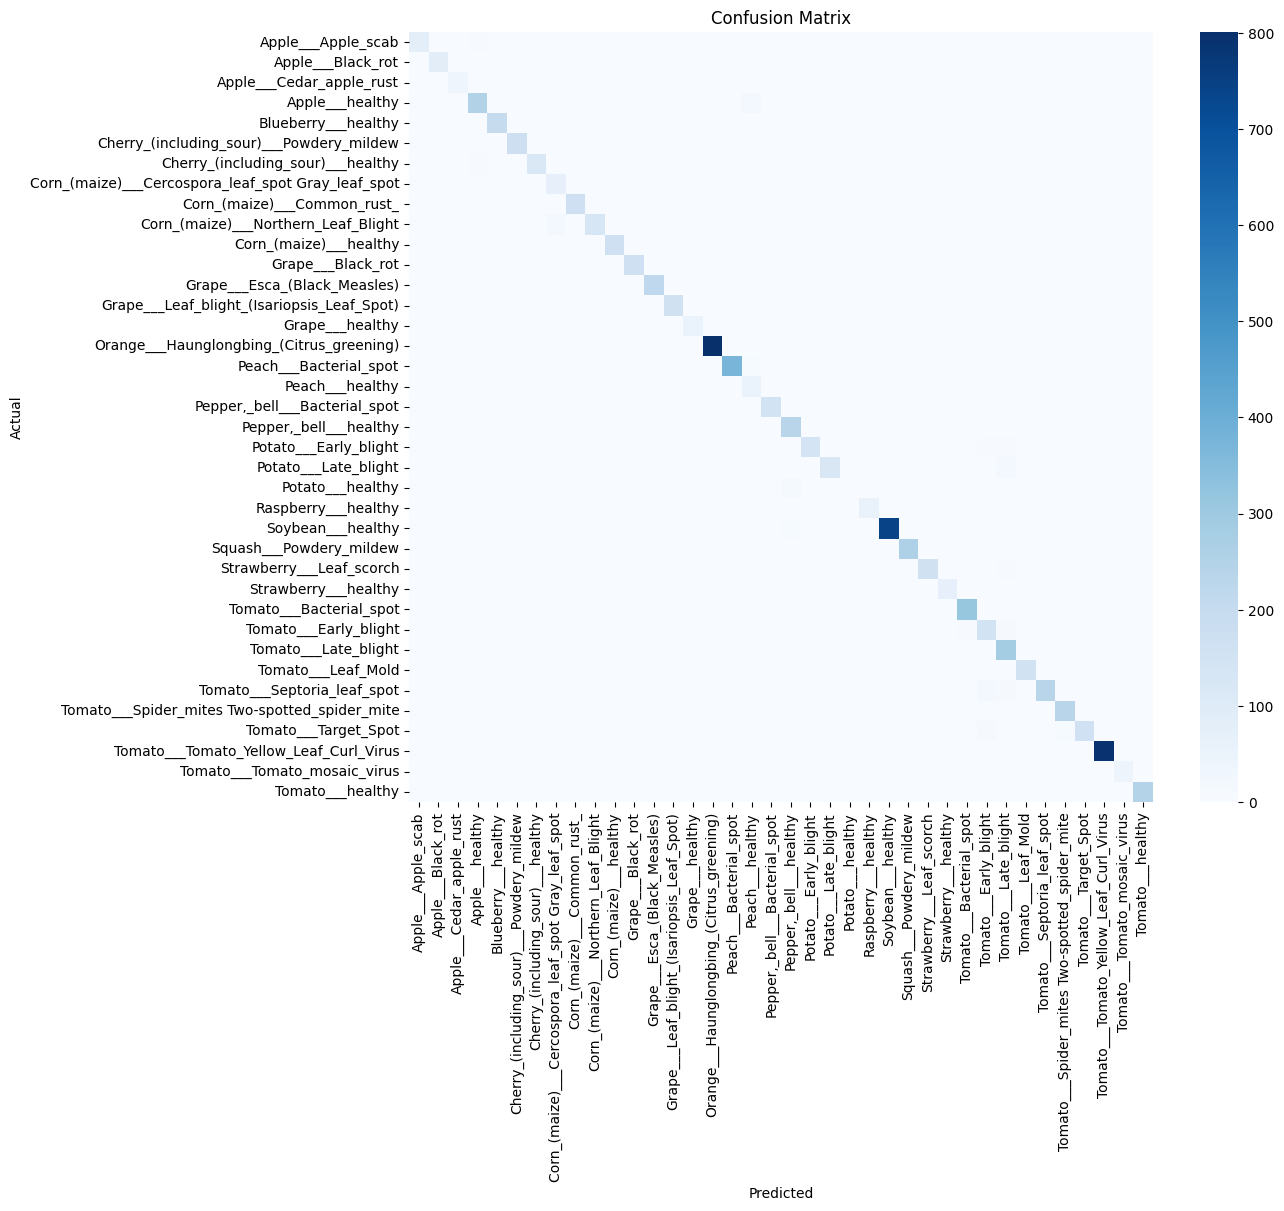

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()